# Robot Soccer Perception Project

[cite_start]This project focuses on the perception system of a soccer robot, utilizing the **SPQRL Dataset** to identify and locate objects on a soccer field[cite: 2, 62].

---

### 1. The Dataset
[cite_start]The dataset provides images from both upper and lower robot cameras[cite: 55, 60]. Each entry includes:
* [cite_start]**Image Dimensions**: Width and height of the JPEG files[cite: 69].
* [cite_start]**Object Class**: Labels identifying the object as a **ball**, **robot**, or **goalpost**[cite: 63, 72].
* [cite_start]**Bounding Box**: Geometric coordinates ($xmin$, $ymin$, $xmax$, $ymax$) that define the object's location in the image[cite: 73, 74].

---

### 2. Homework Problems
You must solve two distinct problems for this assignment:

#### **Problem 1: Classification**
[cite_start]The goal is to correctly identify the type of object within a given area[cite: 88, 90].
* [cite_start]**Input**: An image and a bounding box[cite: 89].
* [cite_start]**Pre-processing**: You are required to **crop the images to the bounding box** (resulting in variable size inputs) and normalize the data[cite: 92].
* [cite_start]**Output**: The predicted object class[cite: 90].

#### **Problem 2: Regression**
[cite_start]The goal is to determine the exact center point of an object[cite: 93, 95].
* [cite_start]**Input**: A full image and the object class label[cite: 94].
* [cite_start]**Pre-processing**: You must **compute the mean of the bounding box** to use as the target[cite: 96].
* [cite_start]**Constraint**: You **must NOT crop** the images for this task; the model must process the full image[cite: 97].
* [cite_start]**Output**: The mean coordinates of the bounding box[cite: 95].

---

### 3. Evaluation and Requirements
* [cite_start]**Methods**: You must describe the algorithms, configurations, and hyper-parameter searches used for each robot's solution[cite: 30, 33, 34, 36].
* [cite_start]**Performance**: Metrics must be provided, such as plots of results over training steps and computational training time[cite: 35, 40].
* [cite_start]**Criteria**: Evaluation is based on the **appropriateness and correctness** of the solution, provided the numeric results are reasonable[cite: 51].

In [4]:
import gdown
import os

file_id = '1mr8Ks3rm-KuMFiJI2pu79TKJ0lbmgnbz'
url = f'https://drive.google.com/uc?id={file_id}'
output_file = 'soccer_dataset.zip'

if os.path.exists(output_file):
  print(f"File '{output_file}' already exists. Skipping download.")
else:

  gdown.download(url, output_file, quiet=False)

output_folder = 'soccer_data'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)


if not os.path.exists(os.path.join(output_folder,'spqr_dataset')):
  !unzip -q {output_file} -d {output_folder}

  print(f"Dataset extracted to: {output_folder}")

Downloading...
From (original): https://drive.google.com/uc?id=1mr8Ks3rm-KuMFiJI2pu79TKJ0lbmgnbz
From (redirected): https://drive.google.com/uc?id=1mr8Ks3rm-KuMFiJI2pu79TKJ0lbmgnbz&confirm=t&uuid=871ddb94-705e-4533-b7a5-8e5131bb3753
To: /content/soccer_dataset.zip
100%|██████████| 60.3M/60.3M [00:01<00:00, 44.9MB/s]


Dataset extracted to: soccer_data


In [5]:
import pandas as pd
import os

base_dir = 'soccer_data/spqr_dataset'
csv_path = os.path.join(base_dir, 'raw/bbx_annotations.csv')
images_dir = os.path.join(base_dir, 'images')

df = pd.read_csv(csv_path, sep=',', header=0)

df.columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

df['full_path'] = df['filename'].apply(lambda x: os.path.join(images_dir, x))

print(f"Columns: {list(df.columns)}")
display(df.head())

Columns: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'full_path']


,filename,width,height,class,xmin,ymin,xmax,ymax,full_path
0,upper_604302_jpg.rf.6215ee30a829ec658154eb4d06...,640,480,goalpost,548,306,595,365,soccer_data/spqr_dataset/images/upper_604302_j...
1,upper_604302_jpg.rf.6215ee30a829ec658154eb4d06...,640,480,ball,0,373,23,419,soccer_data/spqr_dataset/images/upper_604302_j...
2,upper_604302_jpg.rf.6215ee30a829ec658154eb4d06...,640,480,robot,180,88,421,479,soccer_data/spqr_dataset/images/upper_604302_j...
3,lower_529445_jpg.rf.622bcace38eddcf4b59e52a676...,320,240,ball,137,36,193,91,soccer_data/spqr_dataset/images/lower_529445_j...
4,upper_712209_jpg.rf.615664fc7366440b471c06efa7...,640,480,ball,507,376,533,402,soccer_data/spqr_dataset/images/upper_712209_j...


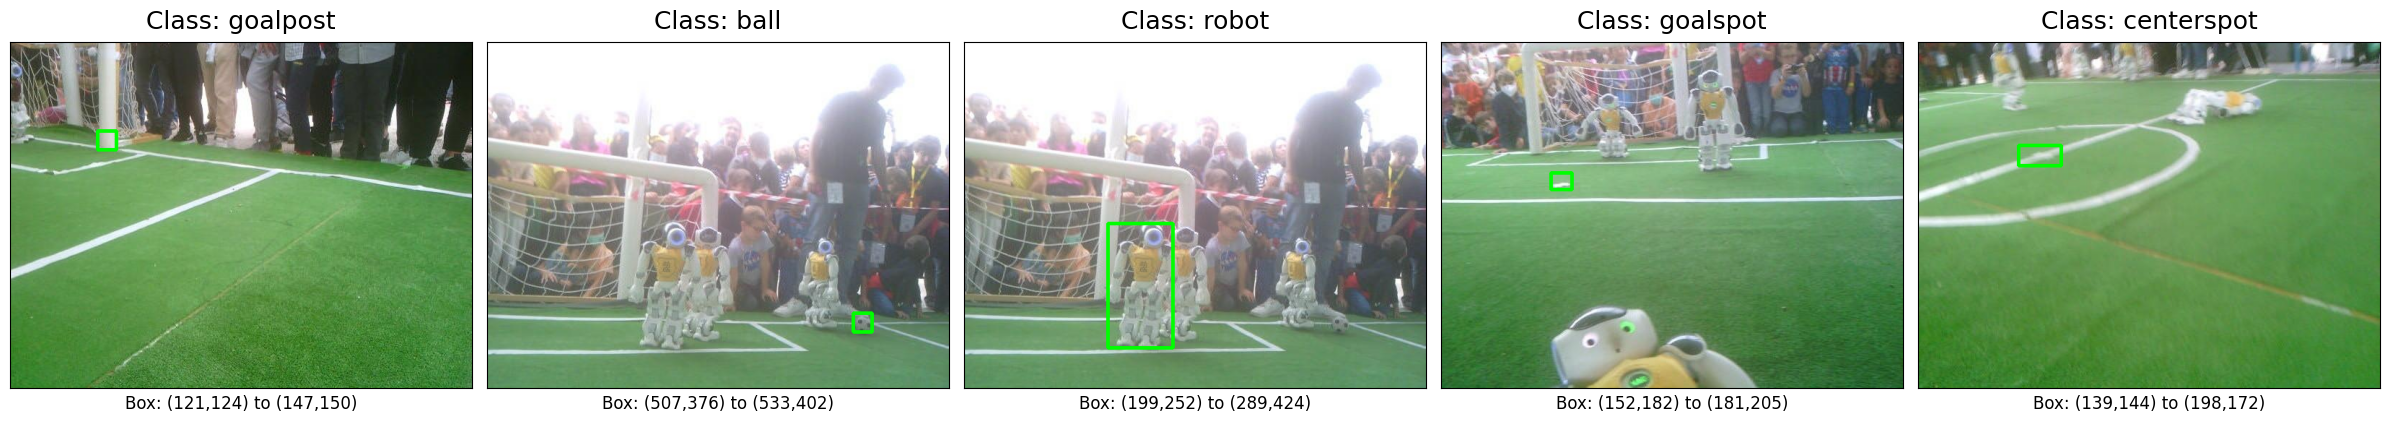

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import glob

images_dirs = glob.glob('soccer_data/**/images', recursive=True)
csv_files = glob.glob('soccer_data/**/bbx_annotations.csv', recursive=True)

if not images_dirs or not csv_files:
    print("Error: Could not find images or CSV.")
else:
    images_dir = images_dirs[0]
    csv_path = csv_files[0]

    df = pd.read_csv(csv_path, sep=',', header=0)
    df.columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

    unique_classes = df['class'].unique()

    fig, axes = plt.subplots(1, len(unique_classes), figsize=(24, 8))
    if len(unique_classes) == 1: axes = [axes]

    for i, obj_class in enumerate(unique_classes):
        class_df = df[df['class'] == obj_class]
        img_found = False

        for _, row in class_df.iterrows():
            img_path = os.path.join(images_dir, row['filename'])
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                x1, y1, x2, y2 = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

                axes[i].imshow(img)
                axes[i].set_title(f"Class: {obj_class}", fontsize=18, pad=10)
                axes[i].set_xlabel(f"Box: ({x1},{y1}) to ({x2},{y2})", fontsize=12)

                img_found = True
                break

        if not img_found:
            axes[i].text(0.5, 0.5, f'No image for {obj_class}', ha='center')

        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()

In [13]:
import tensorflow as tf
import pandas as pd
import os
from sklearn.model_selection import train_test_split

class SoccerDataset:
    def __init__(self, csv_path, images_dir, task='classification', target_class=None, img_size=(64, 64), batch_size=32, seed=42):

        self.images_dir = images_dir
        self.img_size = img_size
        self.batch_size = batch_size
        self.seed = seed
        self.task = task
        self.target_class = target_class

        print(f"{task.upper()} Dataset")
        df_raw = pd.read_csv(csv_path, sep=',', header=0)
        df_raw.columns = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

        self.df = self._find_filenames(df_raw)

        if self.task == 'regression' and self.target_class:
            print(f"Filtering dataset for class: '{self.target_class}' only.")
            self.df = self.df[self.df['class'] == self.target_class].copy()

        self._print_class_stats()

        self.classes = sorted(self.df['class'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.train_df, self.val_df, self.test_df = self._split_data()

    def _print_class_stats(self):
        print("Class Distribution ")
        counts = self.df['class'].value_counts()
        for cls_name, count in counts.items():
            print(f"  {cls_name}: {count} images")
        print(f"  Total: {len(self.df)} images\n")

    def _find_filenames(self, df):
        print("Scanning images...")
        valid_files_map = {}
        files_on_disk = os.listdir(self.images_dir)

        for real_filename in files_on_disk:
            if '.rf.' in real_filename:
                key = real_filename.split('.rf.')[0]
            else:
                key = os.path.splitext(real_filename)[0]
            valid_files_map[key] = real_filename

        valid_rows = []
        for idx, row in df.iterrows():
            csv_filename = row['filename']
            full_path = os.path.join(self.images_dir, csv_filename)

            if os.path.exists(full_path):
                valid_rows.append(row)
                continue

            if '.rf.' in csv_filename:
                key = csv_filename.split('.rf.')[0]
            else:
                key = os.path.splitext(csv_filename)[0]

            if key in valid_files_map:
                row['filename'] = valid_files_map[key]
                valid_rows.append(row)

        return pd.DataFrame(valid_rows)

    def _split_data(self):
        try:
            train, temp = train_test_split(self.df, test_size=0.30, stratify=self.df['class'], random_state=self.seed)
            val, test = train_test_split(temp, test_size=0.50, stratify=temp['class'], random_state=self.seed)
        except ValueError:
            train, temp = train_test_split(self.df, test_size=0.30, random_state=self.seed)
            val, test = train_test_split(temp, test_size=0.50, random_state=self.seed)
        return train, val, test


    def _preprocess_classification(self, filename, bbox, label):
        img_path = tf.strings.join([self.images_dir, os.sep, filename])
        img = tf.io.decode_jpeg(tf.io.read_file(img_path), channels=3)

        ymin, xmin, ymax, xmax = bbox[0], bbox[1], bbox[2], bbox[3]
        height = tf.maximum(ymax - ymin, 1)
        width = tf.maximum(xmax - xmin, 1)

        img_cropped = tf.image.crop_to_bounding_box(img, ymin, xmin, height, width)
        img_resized = tf.image.resize(img_cropped, self.img_size)

        return img_resized / 255.0, label

    def _preprocess_regression(self, filename, label, bbox_norm):
        img_path = tf.strings.join([self.images_dir, os.sep, filename])
        img = tf.io.decode_jpeg(tf.io.read_file(img_path), channels=3)

        img_resized = tf.image.resize(img, self.img_size)

        # Returns tuple of inputs (image, class) and target (mean bbox)
        return (img_resized / 255.0, label), bbox_norm


    def _create_tf_dataset(self, dataframe, shuffle=False):
        filenames = dataframe['filename'].values

        if self.task == 'classification':
            labels = dataframe['class'].map(self.class_to_idx).values
            bboxes = dataframe[['ymin', 'xmin', 'ymax', 'xmax']].values.astype('int32')

            ds = tf.data.Dataset.from_tensor_slices((filenames, bboxes, labels))
            ds = ds.map(self._preprocess_classification, num_parallel_calls=tf.data.AUTOTUNE)

        elif self.task == 'regression':
            labels = dataframe['class'].map(self.class_to_idx).values

            center_x = (dataframe['xmin'] + dataframe['xmax']) / 2.0
            center_y = (dataframe['ymin'] + dataframe['ymax']) / 2.0

            norm_x = center_x / dataframe['width']
            norm_y = center_y / dataframe['height']

            targets = tf.stack([norm_x.values, norm_y.values], axis=1)
            targets = tf.cast(targets, tf.float32)

            ds = tf.data.Dataset.from_tensor_slices((filenames, labels, targets))
            ds = ds.map(self._preprocess_regression, num_parallel_calls=tf.data.AUTOTUNE)

        if shuffle:
            ds = ds.shuffle(buffer_size=1000)

        return ds.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)

    def get_train_dataset(self): return self._create_tf_dataset(self.train_df, shuffle=True)
    def get_val_dataset(self): return self._create_tf_dataset(self.val_df, shuffle=False)
    def get_test_dataset(self): return self._create_tf_dataset(self.test_df, shuffle=False)

In [14]:
dataset = SoccerDataset(csv_path, images_dir)
train_ds = dataset.get_train_dataset()
val_ds = dataset.get_val_dataset()
test_ds = dataset.get_test_dataset()

CLASSIFICATION Dataset
Scanning images...
Class Distribution 
  robot: 3328 images
  goalpost: 773 images
  ball: 672 images
  goalspot: 480 images
  centerspot: 213 images
  Total: 5466 images



In [24]:
def run_training(model, train_ds, val_ds, task_type='classification', epochs=50, model_name='model.keras',resume=False):

    if resume and os.path.exists(model_name):
        print(f"Found checkpoint '{model_name}'. Loading weights to resume training...")
        try:
            model.load_weights(model_name)
            print("Weights loaded successfully. Resuming training.")
        except Exception as e:
            print(f"Warning: Could not load weights ({e}). Starting from scratch.")
    else:
        if resume:
            print(f"Resume requested but '{model_name}' not found.")
        print("Starting training from scratch...")

    if task_type == 'classification':
        loss_fn = 'sparse_categorical_crossentropy'
        metric_list = ['accuracy']
        monitor_metric = 'val_loss'
        print("Configuring for CLASSIFICATION (Crossentropy)")

    elif task_type == 'regression':
        loss_fn = 'mse'
        metric_list = ['mae']
        monitor_metric = 'val_loss'
        print("Configuring for REGRESSION (MSE)")

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.001,
        decay_steps=epochs * len(train_ds)
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=metric_list)

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            model_name,
            monitor=monitor_metric,
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor_metric,
            patience=10,
            restore_best_weights=True
        )
    ]

    print(f"Starting training for {epochs} epochs")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )

    return history

In [25]:
def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [26]:
def create_cnn_model(input_shape=(64, 64, 3), num_classes=3, learning_rate=0.001):

    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,493 (4.36 MB)

 Trainable params: 1,143,045 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

--- Setup for sequential_8 ---
Starting training from scratch...
Training for 1000 epochs
Epoch 1/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.7782 - loss: 0.9060 - val_accuracy: 0.1415 - val_loss: 5.3991 - learning_rate: 0.0010
Epoch 2/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9104 - loss: 0.3039 - val_accuracy: 0.2061 - val_loss: 7.9485 - learning_rate: 0.0010
Epoch 3/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9266 - loss: 0.2423 - val_accuracy: 0.3451 - val_loss: 3.3857 - learning_rate: 0.0010
Epoch 4/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9255 - loss: 0.2448 - val_accuracy: 0.6293 - val_loss: 2.1506 - learning_rate: 0.0010
Epoch 5/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9276 - loss: 0.2441 - val_accuracy: 0.8951 - val_loss: 0.3110 - learning_rate: 0.0010
Epoch 6/1000
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9430 - loss: 0.1854 - val_accuracy: 0.9476 - val_loss: 0.1477 - l

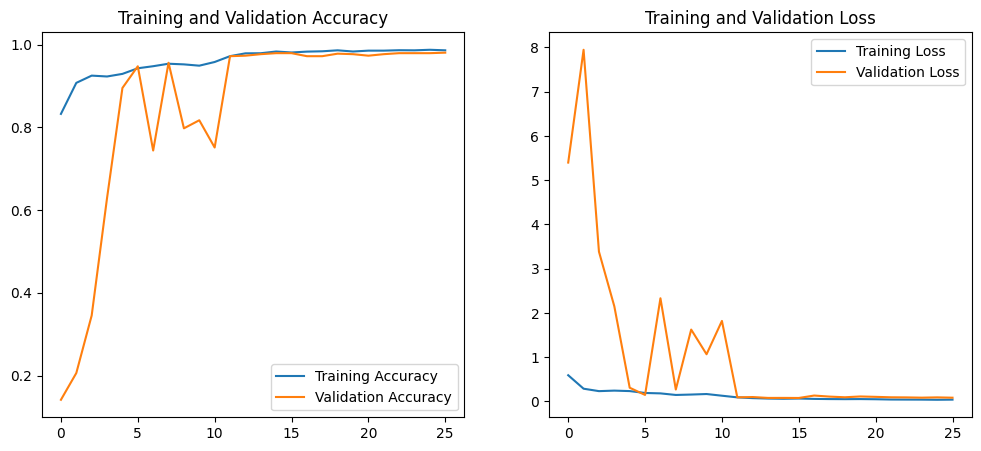


Evaluating on Test Set...
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9738 - loss: 0.1190
Test Accuracy: 97.07%


In [47]:
model = create_cnn_model(input_shape=(64, 64, 3), num_classes=5)
model.summary()

history = run_training(model, train_ds, val_ds, epochs=1000, model_name='robot_soccer_cnn_v1.keras')

plot_training_history(history)

print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

In [50]:
def create_advanced_model(input_shape=(64, 64, 3), num_classes=5):
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ])

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        data_augmentation,

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [55]:
advanced_model = create_advanced_model(input_shape=(64, 64, 3), num_classes=5)

history_adv = run_training(advanced_model, train_ds, val_ds, epochs=200, model_name='model_v2_aug.keras')


Starting Advanced Training with Augmentation & Cosine Decay...
Epoch 1/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.7855 - loss: 0.6991 - val_accuracy: 0.1415 - val_loss: 7.4360
Epoch 2/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9124 - loss: 0.2686 - val_accuracy: 0.1646 - val_loss: 10.0736
Epoch 3/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9410 - loss: 0.1941 - val_accuracy: 0.2915 - val_loss: 4.3999
Epoch 4/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9425 - loss: 0.1635 - val_accuracy: 0.3768 - val_loss: 2.1700
Epoch 5/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9518 - loss: 0.1693 - val_accuracy: 0.9561 - val_loss: 0.1426
Epoch 6/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9600 - loss: 0.1312 - val_accuracy: 0.9451 - val_loss: 0.1463
Epoch 7/200
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9555 - loss: 0.1301 - val_accuracy: 0.7354 - val_loss: 0.9146
Epoch 8/200
120/120 ━━

In [56]:
advanced_model.save('final_advanced_model.keras')

Model saved successfully.


In [16]:
reg_dataset = SoccerDataset(
    csv_path=csv_path,
    images_dir=images_dir,
    task='regression',
    img_size=(128, 128),
    batch_size=32
)

train_reg_ds = reg_dataset.get_train_dataset()
val_reg_ds = reg_dataset.get_val_dataset()
test_reg_ds = reg_dataset.get_test_dataset()

(img_batch, class_batch), target_batch = next(iter(train_reg_ds))

print(f"Image Batch Shape: {img_batch.shape}")
print(f"Class Batch Shape: {class_batch.shape}")
print(f"Target Batch Shape: {target_batch.shape}")

REGRESSION Dataset
Scanning images...
Class Distribution 
  robot: 3328 images
  goalpost: 773 images
  ball: 672 images
  goalspot: 480 images
  centerspot: 213 images
  Total: 5466 images

Image Batch Shape: (32, 128, 128, 3)
Class Batch Shape: (32,)
Target Batch Shape: (32, 2)


In [29]:
def plot_smart_history(history):
    # 1. Identify the metric used
    history_dict = history.history

    if 'accuracy' in history_dict:
        metric = 'accuracy'
        val_metric = 'val_accuracy'
        label = 'Accuracy (Higher is Better)'
    elif 'mae' in history_dict:
        metric = 'mae'
        val_metric = 'val_mae'
        label = 'Mean Absolute Error (Lower is Better)'
    else:
        print("Unknown metric found in history.")
        return

    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs = range(1, len(loss) + 1)

    # 2. Plot
    plt.figure(figsize=(14, 5))

    # Subplot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()

    # Subplot 2: The Metric (Accuracy or MAE)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict[metric], 'bo-', label=f'Training {metric.upper()}')
    plt.plot(epochs, history_dict[val_metric], 'ro-', label=f'Validation {val_metric.upper()}')
    plt.title(f'Training and Validation {label}')
    plt.xlabel('Epochs')
    plt.ylabel(metric.upper())
    plt.legend()

    plt.show()


In [20]:
def create_conditional_regression_model(input_shape=(64, 64, 3), num_classes=5):
    # --- 1. THE VISUAL BRANCH (CNN) ---
    img_input = tf.keras.layers.Input(shape=input_shape, name='image_input')

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(img_input)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Feature Extractor
    # GlobalAveragePooling is better than Flatten here because it keeps spatial info
    # summarized efficiently without massive parameter counts.
    visual_features = tf.keras.layers.GlobalAveragePooling2D()(x)

    # --- 2. THE CLASS BRANCH (Context) ---
    class_input = tf.keras.layers.Input(shape=(1,), name='class_input')

    # Embedding Layer: Learns a unique "vector representation" for each class
    # e.g., "Ball" becomes [0.1, -0.5, 0.8, ...] which helps the dense layers distinguish it.
    class_features = tf.keras.layers.Embedding(input_dim=num_classes, output_dim=16)(class_input)
    class_features = tf.keras.layers.Flatten()(class_features)

    # --- 3. FUSION ---
    # Merge the Visual info with the Class info
    combined = tf.keras.layers.Concatenate()([visual_features, class_features])

    # --- 4. REGRESSION HEAD ---
    z = tf.keras.layers.Dense(128, activation='relu')(combined)
    z = tf.keras.layers.Dropout(0.2)(z) # Prevent overfitting
    z = tf.keras.layers.Dense(64, activation='relu')(z)

    # --- 5. OUTPUT ---
    # Units=2 because we predict [x_center, y_center]
    # Activation='sigmoid' forces output to be between 0.0 and 1.0 (perfect for normalized coords)
    output = tf.keras.layers.Dense(2, activation='sigmoid', name='output')(z)

    # Create the Model
    model = tf.keras.Model(inputs=[img_input, class_input], outputs=output, name="Conditional_Regressor")

    return model

Model: "Conditional_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 16)     │         80 │ class_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_14… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 144)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     18,560 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0] 

 Total params: 121,170 (473.32 KB)

 Trainable params: 120,722 (471.57 KB)

 Non-trainable params: 448 (1.75 KB)

Configuring for REGRESSION (MSE)
Starting training for 150 epochs
Epoch 1/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0559 - mae: 0.1870
Epoch 1: val_loss improved from inf to 0.05775, saving model to best_regressor.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - loss: 0.0559 - mae: 0.1870 - val_loss: 0.0577 - val_mae: 0.1985
Epoch 2/150
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0469 - mae: 0.1666
Epoch 2: val_loss did not improve from 0.05775
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0468 - mae: 0.1666 - val_loss: 0.0890 - val_mae: 0.2386
Epoch 3/150
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0439 - mae: 0.1613
Epoch 3: val_loss did not improve from 0.05775
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0439 - mae: 0.1613 - val_loss: 0.0780 - val_mae: 0.2291
Epoch 4/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0424 - mae: 0.1565
Epoch 4: val_loss improved from 0.05775 to 0.05328, saving model to best_regressor.keras
120/120 ━

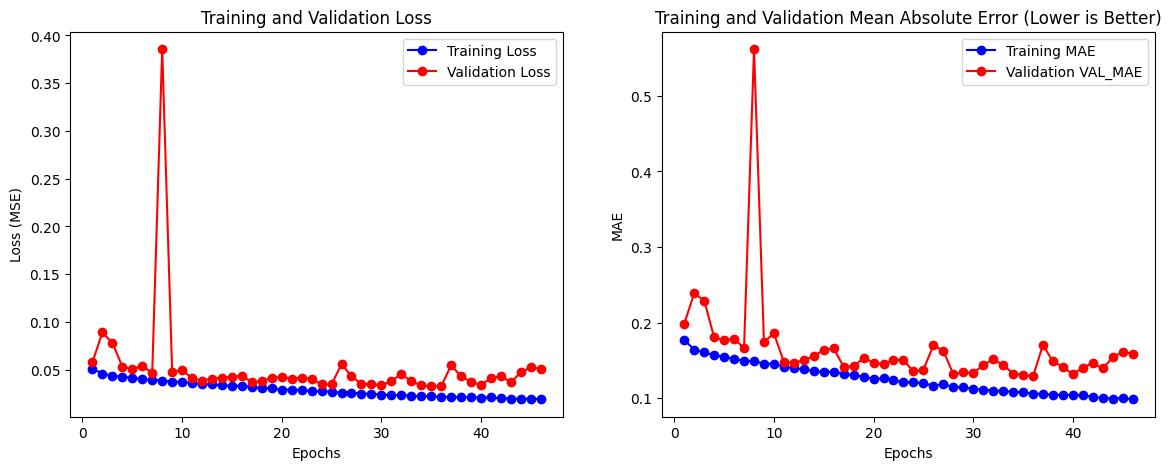

In [30]:
# 1. Create the Model
model = create_conditional_regression_model(
    input_shape=(128, 128, 3),
    num_classes=len(reg_dataset.classes)
)
model.summary()

history = run_training(
    model,
    train_reg_ds,
    val_reg_ds,
    task_type='regression',
    epochs=150,
    model_name='best_regressor.keras'
)

plot_smart_history(history)

Visualizing Test Set Predictions
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


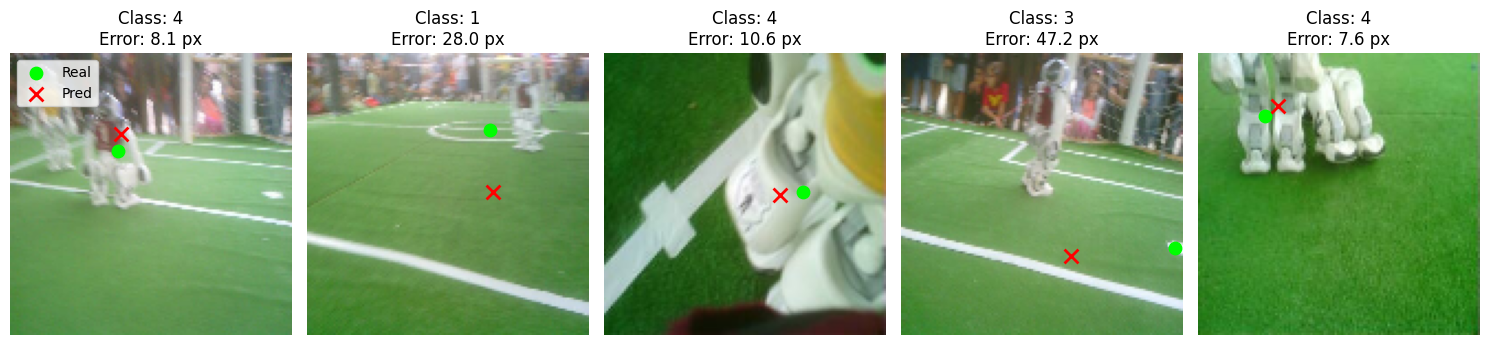

In [32]:
import numpy as np

def visualize_regression_results(model, dataset, num_samples=5):

    (inputs, targets) = next(iter(dataset))
    images_batch, class_ids_batch = inputs

    preds = model.predict([images_batch, class_ids_batch])

    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)

        img = images_batch[i].numpy()
        h, w, _ = img.shape

        true_x_norm, true_y_norm = targets[i].numpy()
        pred_x_norm, pred_y_norm = preds[i]

        true_x = true_x_norm * w
        true_y = true_y_norm * h

        pred_x = pred_x_norm * w
        pred_y = pred_y_norm * h

        plt.imshow(img)

        plt.scatter(true_x, true_y, c='lime', s=80, marker='o', label='Real')

        plt.scatter(pred_x, pred_y, c='red', s=100, marker='x', linewidth=2, label='Pred')

        dist = np.sqrt((true_x - pred_x)**2 + (true_y - pred_y)**2)
        plt.title(f"Class: {int(class_ids_batch[i])}\nError: {dist:.1f} px")
        plt.axis('off')

        if i == 0:
            plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

try:
    print("Visualizing Test Set Predictions")
    test_reg_ds = reg_dataset.get_test_dataset()
    visualize_regression_results(model, test_reg_ds)
except:
    print("Test set not found, visualizing Validation Set")
    visualize_regression_results(model, val_reg_ds)

In [33]:
import numpy as np

def evaluate_error_by_class(model, dataset, class_names, img_size=128):
    print("Evaluating Error by Class")

    class_errors = {i: [] for i in range(len(class_names))}

    for (inputs, targets) in dataset:
        images_batch, class_ids_batch = inputs

        preds = model.predict([images_batch, class_ids_batch], verbose=0)

        diff = preds - targets.numpy()

        dist_norm = np.sqrt(np.sum(diff**2, axis=1))
        dist_pixels = dist_norm * img_size

        for i, class_id in enumerate(class_ids_batch):
            class_int = int(class_id)
            class_errors[class_int].append(dist_pixels[i])

    print(f"Results (Image Size: {img_size}x{img_size}):")
    print(f"{'Class Name':<15} | {'Count':<8} | {'Avg Error (px)':<15}")
    print("-" * 45)

    total_error = []

    for class_id, errors in class_errors.items():
        if len(errors) > 0:
            avg_error = np.mean(errors)
            count = len(errors)
            name = class_names[class_id]

            print(f"{name:<15} | {count:<8} | {avg_error:.2f} px")
            total_error.extend(errors)
        else:
            print(f"{class_names[class_id]:<15} | 0        | N/A")

    print("-" * 45)
    print(f"{'OVERALL':<15} | {len(total_error):<8} | {np.mean(total_error):.2f} px")

class_names = list(reg_dataset.class_to_idx.keys())
evaluate_error_by_class(model, val_reg_ds, class_names, img_size=128)

Evaluating Error by Class
Results (Image Size: 128x128):
Class Name      | Count    | Avg Error (px) 
---------------------------------------------
ball            | 101      | 27.77 px
centerspot      | 32       | 23.17 px
goalpost        | 116      | 23.57 px
goalspot        | 72       | 25.01 px
robot           | 499      | 28.66 px
---------------------------------------------
OVERALL         | 820      | 27.30 px


In [34]:
def augment_regression_data(inputs, target):
    """
    Applies augmentation to Image AND updates the Regression Target (x, y)
    inputs: tuple (image, class_id)
    target: tensor [x_norm, y_norm]
    """
    image, class_id = inputs
    x, y = target[0], target[1] # Unpack coordinates

    # --- 1. Color Augmentations (Safe: Coords don't change) ---
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

    # --- 2. Geometric Augmentation (Horizontal Flip) ---
    # We flip with 50% probability
    do_flip = tf.random.uniform([]) > 0.5

    def flip_fn():
        # Flip image
        flipped_img = tf.image.flip_left_right(image)
        # Flip Coordinate: New X is (1.0 - Old X)
        new_x = 1.0 - x
        return flipped_img, new_x

    def no_flip_fn():
        return image, x

    # Execute based on random choice
    final_img, final_x = tf.cond(do_flip, flip_fn, no_flip_fn)

    # Clip image to 0-1 range after color math
    final_img = tf.clip_by_value(final_img, 0.0, 1.0)

    # Re-pack the target
    new_target = tf.stack([final_x, y], axis=0)

    return (final_img, class_id), new_target

In [37]:
# 1. Get the base training dataset (shuffled but not batched yet if possible,
# but since your class batches it, we map over the batches or unbatch)

# Easier method: Apply to the dataset object directly
train_reg_ds = reg_dataset.get_train_dataset() # This is already batched

# We need to unbatch to apply per-item augmentation logic easily, then rebatch
# OR map function can handle it if we are careful.
# Let's use map on the unbatched stream for safety in this context.

# A. Re-create train dataset manually to insert augmentation
def get_augmented_train_dataset(dataset_obj):
    # 1. Basic Setup (Same as class)
    filenames = dataset_obj.train_df['filename'].values
    labels = dataset_obj.train_df['class'].map(dataset_obj.class_to_idx).values

    # Targets
    center_x = (dataset_obj.train_df['xmin'] + dataset_obj.train_df['xmax']) / 2.0
    center_y = (dataset_obj.train_df['ymin'] + dataset_obj.train_df['ymax']) / 2.0
    norm_x = center_x / dataset_obj.train_df['width']
    norm_y = center_y / dataset_obj.train_df['height']
    targets = tf.stack([norm_x.values, norm_y.values], axis=1).numpy().astype('float32')

    # 2. Create Dataset
    ds = tf.data.Dataset.from_tensor_slices((filenames, labels, targets))

    # 3. Load Images & Preprocess (The standard step)
    ds = ds.map(dataset_obj._preprocess_regression, num_parallel_calls=tf.data.AUTOTUNE)

    # 4. APPLY AUGMENTATION (The New Step)
    ds = ds.map(augment_regression_data, num_parallel_calls=tf.data.AUTOTUNE)

    # 5. Shuffle & Batch
    ds = ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
    return ds


In [36]:
def residual_block(x, filters):
    """
    A ResNet block: Input -> [Conv-BN-Relu-Conv-BN] + Input -> Relu
    """
    shortcut = x

    # Layer 1
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Layer 2
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Adjust shortcut if dimensions don't match (e.g. if we changed filters)
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(shortcut)

    # The Magic "Skip Connection"
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

def create_advanced_resnet(input_shape=(128, 128, 3), num_classes=5):
    # --- Visual Branch ---
    img_input = tf.keras.layers.Input(shape=input_shape, name='image')

    # Entry Block
    x = tf.keras.layers.Conv2D(32, (7, 7), strides=2, padding='same')(img_input)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Residual Stages
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = residual_block(x, 256)

    # Global Pooling (The compactor)
    visual_features = tf.keras.layers.GlobalAveragePooling2D()(x)

    # --- Class Branch ---
    class_input = tf.keras.layers.Input(shape=(1,), name='class_id')
    class_features = tf.keras.layers.Embedding(num_classes, 32)(class_input)
    class_features = tf.keras.layers.Flatten()(class_features)

    # --- Fusion ---
    combined = tf.keras.layers.Concatenate()([visual_features, class_features])

    # --- Regressor Head ---
    z = tf.keras.layers.Dense(256, activation='relu')(combined)
    z = tf.keras.layers.Dropout(0.3)(z) # Slightly higher dropout for larger model
    z = tf.keras.layers.Dense(128, activation='relu')(z)

    output = tf.keras.layers.Dense(2, activation='sigmoid', name='coords')(z)

    model = tf.keras.Model(inputs=[img_input, class_input], outputs=output)
    return model

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │      4,736 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 32, 32,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_12[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │      2,112 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_32[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 32, 32,    │          0 │ add_5[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_13[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_14[0]

 Total params: 1,691,874 (6.45 MB)

 Trainable params: 1,689,250 (6.44 MB)

 Non-trainable params: 2,624 (10.25 KB)

Configuring for REGRESSION (MSE)
Starting training for 150 epochs
Epoch 1/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0380 - mae: 0.1427
Epoch 1: val_loss improved from inf to 0.04604, saving model to best_regressor_augmented.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0380 - mae: 0.1427 - val_loss: 0.0460 - val_mae: 0.1637
Epoch 2/150
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0342 - mae: 0.1367
Epoch 2: val_loss improved from 0.04604 to 0.03443, saving model to best_regressor_augmented.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.0342 - mae: 0.1367 - val_loss: 0.0344 - val_mae: 0.1354
Epoch 3/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0339 - mae: 0.1364
Epoch 3: val_loss did not improve from 0.03443
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0339 - mae: 0.1364 - val_loss: 0.0381 - val_mae: 0.1473
Epoch 4/150
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0333 - mae: 0.1347
Epoch 4: val_loss did not improve f

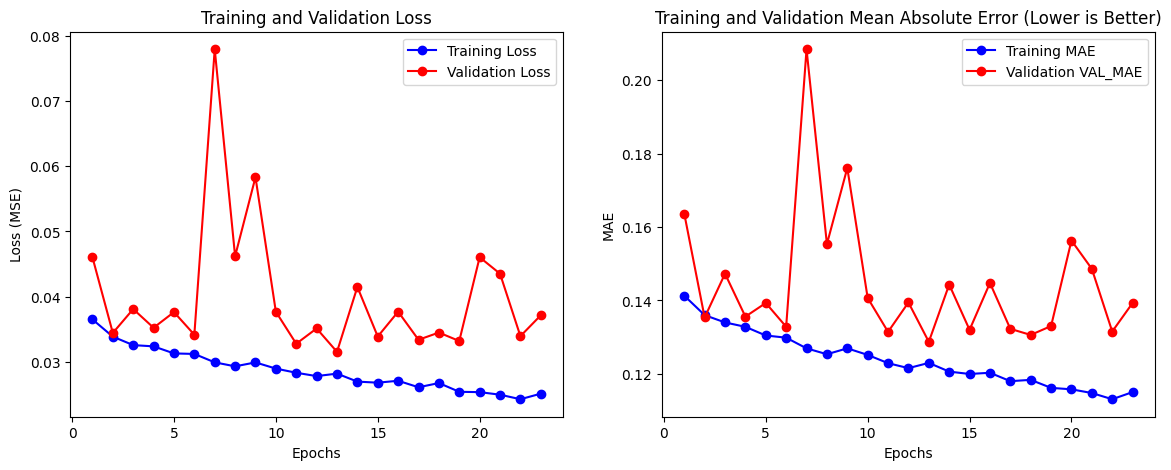

In [39]:
resnet_model = create_advanced_resnet(input_shape=(128, 128, 3), num_classes=len(reg_dataset.classes))
resnet_model.summary()

augmented_train_ds = get_augmented_train_dataset(reg_dataset)


history_res = run_training(
    model,
    augmented_train_ds,
    val_reg_ds,
    task_type='regression',
    epochs=150,
    model_name='best_regressor_augmented.keras'
)

plot_smart_history(history_res)